In [1]:
import datacube
dc = datacube.Datacube()

In [8]:
dc.list_products()

,name,description,license,default_crs,default_resolution
name,,,,,
cmems_poc,cmems_poc,CMEMS L4 3D BGC monthly climatology of particu...,proprietary,EPSG:4326,"Resolution(x=0.25, y=-0.25)"
cmems_sss,cmems_sss,CMEMS L4 multi-sensor sea surface salinity on ...,proprietary,EPSG:4326,"Resolution(x=0.125, y=-0.125)"
s3_olci_chl,s3_olci_chl,Sentinel-3 OLCI Level-2 Water Full Resolution ...,proprietary,EPSG:4326,"Resolution(x=0.003, y=-0.003)"
s3_slstr_sst,s3_slstr_sst,Sentinel-3 SLSTR Level-2 sea surface temperatu...,proprietary,EPSG:4326,"Resolution(x=0.01, y=-0.01)"
sentinel_2_ard,sentinel_2_ard,Sentinel-2 Analysis Ready Data (ARD) from the ...,None,EPSG:27700,"Resolution(x=10, y=-10)"


In [5]:
bbox=[10.706177,56.857983,12.683716,58.788132]


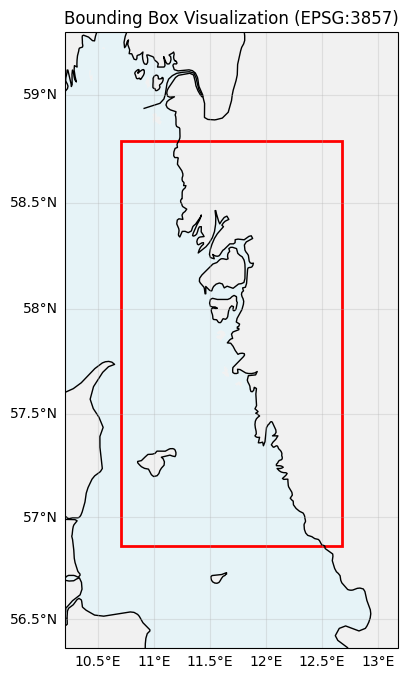

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a plot with EPSG:3857 projection (Web Mercator)
fig, ax = plt.subplots(figsize=(10, 8), 
                       subplot_kw={'projection': ccrs.epsg(3857)})

# Extract bounding box coordinates
min_lon, min_lat, max_lon, max_lat = bbox

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

# Create a rectangle for the bounding box (in PlateCarree/WGS84 coordinates)
rect = Rectangle((min_lon, min_lat), 
                 max_lon - min_lon, 
                 max_lat - min_lat,
                 linewidth=2, 
                 edgecolor='red', 
                 facecolor='none',
                 transform=ccrs.PlateCarree())

# Add the rectangle to the plot
ax.add_patch(rect)

# Set the plot extent with some padding (in PlateCarree coordinates)
padding = 0.5
ax.set_extent([min_lon - padding, max_lon + padding, 
               min_lat - padding, max_lat + padding], 
              crs=ccrs.PlateCarree())

# Add gridlines
gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False

# Add title
ax.set_title('Bounding Box Visualization (EPSG:3857)')

# Display the plot
plt.show()


In [70]:
# Define the time range
time_range = ('2021-05-01', '2021-08-31')

# Define resolution
resolution = 0.25   # use the lowest resolution in the dataset collection

# Query and load Sea Surface Salinity (SSS)
sss_data = dc.load(product='cmems_sss',
                   measurements=['sos'],
                   x=(bbox[0], bbox[2]),
                   y=(bbox[1], bbox[3]),
                   time=time_range,
                   resolution=resolution,
                   output_crs='EPSG:4326')

Querying product Product(name='cmems_sss', id_=13)


In [71]:
# Query and load Sea Surface Temperature (SST)
sst_data = dc.load(product='s3_slstr_sst',
                   measurements=['sea_surface_temperature'],
                   x=(bbox[0], bbox[2]),
                   y=(bbox[1], bbox[3]),
                   time=time_range,
                   resolution=resolution,
                   output_crs='EPSG:4326')

Querying product Product(name='s3_slstr_sst', id_=16)


In [67]:
# Query and load Chlorophyll (CHL)
chl_data = dc.load(product='s3_olci_chl',
                   measurements=['CHL_NN'],
                   x=(bbox[0], bbox[2]),
                   y=(bbox[1], bbox[3]),
                   time=time_range,
                   resolution=resolution,
                   output_crs='EPSG:4326')

Querying product Product(name='s3_olci_chl', id_=15)


In [72]:
# Compute daily mean SST
sst_data = sst_data.resample(time='1D').mean()

In [73]:
# Adjust SST from Kelvin to Celsius
sst_data['sea_surface_temperature'] = sst_data['sea_surface_temperature'] - 273.15

In [97]:
# Compute daily mean CHL
chl_data = chl_data.resample(time='1D').mean()

In [98]:
# Check spatial and temporal coordinates
print("\n=== Coordinate Information ===")
print(f"SSS - Time: {len(sss_data.time)}, X: {len(sss_data.longitude)}, Y: {len(sss_data.latitude)}")
#print(f"POC - Time: {len(poc_data.time)}, X: {len(poc_data.longitude)}, Y: {len(poc_data.latitude)}")
print(f"SST - Time: {len(sst_data.time)}, X: {len(sst_data.longitude)}, Y: {len(sst_data.latitude)}")
print(f"CHL - Time: {len(chl_data.time)}, X: {len(chl_data.longitude)}, Y: {len(chl_data.latitude)}")



=== Coordinate Information ===
SSS - Time: 165, X: 9, Y: 9
SST - Time: 165, X: 9, Y: 9
CHL - Time: 123, X: 9, Y: 9


In [99]:
import pandas as pd
import numpy as np

# Get the full temporal range across all datasets
all_times = np.unique(np.concatenate([
    sss_data.time.values,
    sst_data.time.values,
    chl_data.time.values
]))

# Sort the times
all_times = np.sort(all_times)

print("\n=== Temporal Alignment ===")
print(f"Total unique time steps across all datasets: {len(all_times)}")
print(f"Full time range: {all_times[0]} to {all_times[-1]}")
print(f"\nOriginal time steps:")
print(f"  SSS: {len(sss_data.time)}")
print(f"  SST: {len(sst_data.time)}")
print(f"  CHL: {len(chl_data.time)}")

# Reindex each dataset to cover the full temporal range
sss_data = sss_data.reindex(time=all_times, fill_value=np.nan)
sst_data = sst_data.reindex(time=all_times, fill_value=np.nan)
chl_data = chl_data.reindex(time=all_times, fill_value=np.nan)

print(f"\nAfter temporal alignment:")
print(f"  SSS: {len(sss_data.time)}")
print(f"  SST: {len(sst_data.time)}")
print(f"  CHL: {len(chl_data.time)}")

# Verify that all datasets now have the same time coordinates
assert len(sss_data.time) == len(sst_data.time) == len(chl_data.time), "Time dimensions don't match!"
assert np.all(sss_data.time.values == sst_data.time.values), "SSS and SST time coordinates don't match!"
assert np.all(sss_data.time.values == chl_data.time.values), "SSS and CHL time coordinates don't match!"

print("\n✓ All datasets now cover the full temporal range with NaN values where data was missing")


=== Temporal Alignment ===
Total unique time steps across all datasets: 165
Full time range: 2021-05-01T00:00:00.000000000 to 2021-08-31T10:04:33.000000000

Original time steps:
  SSS: 165
  SST: 165
  CHL: 123

After temporal alignment:
  SSS: 165
  SST: 165
  CHL: 165

✓ All datasets now cover the full temporal range with NaN values where data was missing


In [100]:
import xarray as xr

# Combine all three datasets into a single xarray Dataset
combined_data = xr.Dataset({
    'salinity': sss_data['sos'],
    'temperature': sst_data['sea_surface_temperature'],
    'chlorophyll': chl_data['CHL_NN']
})

# Display information about the combined dataset
print("\n=== Combined Dataset Information ===")
print(combined_data)
print(f"\nVariables: {list(combined_data.data_vars)}")
print(f"Dimensions: {dict(combined_data.sizes)}")
print(f"Coordinates: {list(combined_data.coords)}")


=== Combined Dataset Information ===
<xarray.Dataset> Size: 162kB
Dimensions:      (time: 165, latitude: 9, longitude: 9)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2021-05-01 ... 2021-08-31T10:04:33
  * latitude     (latitude) float64 72B 58.88 58.62 58.38 ... 57.38 57.12 56.88
  * longitude    (longitude) float64 72B 10.62 10.88 11.12 ... 12.12 12.38 12.62
    spatial_ref  int32 4B 4326
Data variables:
    salinity     (time, latitude, longitude) float32 53kB 27.06 26.67 ... nan
    temperature  (time, latitude, longitude) float32 53kB nan nan ... nan nan
    chlorophyll  (time, latitude, longitude) float32 53kB nan nan ... nan nan

Variables: ['salinity', 'temperature', 'chlorophyll']
Dimensions: {'time': 165, 'latitude': 9, 'longitude': 9}
Coordinates: ['time', 'latitude', 'longitude', 'spatial_ref']


In [102]:
# Drop the time elements of the time.values, just use the date
combined_data['time'] = combined_data['time'].dt.floor('D')

print("\n=== Time Coordinates Normalized to Dates ===")
print(f"Combined time range: {combined_data.time.values[0]} to {combined_data.time.values[-1]}")


=== Time Coordinates Normalized to Dates ===
Combined time range: 2021-05-01T00:00:00.000000000 to 2021-08-31T00:00:00.000000000


In [107]:
# Visualize the datasets with interactive date picker
from ipywidgets import interact, DatePicker
import numpy as np
import pandas as pd

def plot_timestep(selected_date):
    """Plot all three variables at a specific date"""
    if selected_date is None:
        print("Please select a date")
        return
    
    # Convert selected date to numpy datetime64[ns] to match the data format
    selected_datetime = np.datetime64(selected_date, 'ns')
    
    # Find the nearest time index for each dataset
    try:
        # Check if the selected date exists in any dataset
        combined_dates = combined_data.time.values
        
        # Find nearest time indices
        combined_time_index = np.argmin(np.abs(combined_dates - selected_datetime))
        
    except Exception as e:
        print(f"Error finding data for {selected_date}: {e}")
        return
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    
    # Plot Sea Surface Salinity (SSS)
    combined_data['salinity'].isel(time=combined_time_index).plot(
        ax=axes[0], 
        cmap='viridis', 
        vmin=18,
        vmax=32,
        cbar_kwargs={'label': 'Salinity (PSU)'}, 
        transform=ccrs.PlateCarree()
    )
    axes[0].coastlines(resolution='10m', linewidth=0.8, color='black')
    axes[0].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    axes[0].set_title(f'Sea Surface Salinity\n{str(combined_data.time[combined_time_index].values)[:10]}')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    
    # Plot Sea Surface Temperature (SST)
    combined_data['temperature'].isel(time=combined_time_index).plot(
        ax=axes[1], 
        cmap='RdYlBu_r', 
        vmin=15,
        vmax=24,
        cbar_kwargs={'label': 'Temperature (°C)'}, 
        transform=ccrs.PlateCarree()
    )
    axes[1].coastlines(resolution='10m', linewidth=0.8, color='black')
    axes[1].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    axes[1].set_title(f'Sea Surface Temperature\n{str(combined_data.time[combined_time_index].values)[:10]}')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    
    # Plot Chlorophyll (CHL) with log scale
    combined_data['chlorophyll'].isel(time=combined_time_index).plot(
        ax=axes[2], 
        cmap='YlGn', 
        norm=plt.matplotlib.colors.LogNorm(vmin=0.01, vmax=67.0), 
        cbar_kwargs={'label': 'Chlorophyll (mg/m³)'}, 
        transform=ccrs.PlateCarree()
    )
    axes[2].coastlines(resolution='10m', linewidth=0.8, color='black')
    axes[2].add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')
    axes[2].set_title(f'Chlorophyll Concentration (Log Scale)\n{str(combined_data.time[combined_time_index].values)[:10]}')
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

# Get the date range from all datasets
min_date = pd.Timestamp(combined_data.time.min().values)
max_date = pd.Timestamp(combined_data.time.max().values)

# Create interactive date picker
date_picker = DatePicker(
    description='Select Date:',
    value=min_date,
    disabled=False
)

# Display the date range information
print(f"\n=== Available Date Range ===")
print(f"Start Date: {min_date}")
print(f"End Date: {max_date}")

# Create interactive widget
interact(plot_timestep, selected_date=date_picker)


=== Available Date Range ===
Start Date: 2021-05-01 00:00:00
End Date: 2021-08-31 00:00:00


interactive(children=(DatePicker(value=Timestamp('2021-05-01 00:00:00'), description='Select Date:', step=1), …

<function __main__.plot_timestep(selected_date)>